# 1. 📚 Importar librerias

In [64]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# 2. 📊 Cargar csv/df

In [66]:
'''
        En esta ocasion no es necesario aplicar un df.copy(), ya que la informacion viene de la lista y DF no 
        es una vista de la informacion, es un objeto nuevo.
'''
small_data = '../data/raw/2023-03-08 Precios Casas RM.csv'
large_data = '../data/raw/2023-07-18 Propiedades Web Scrape.csv' 

DTYPES = {
    'Price_UF': 'float32',
    'Built Area': 'float32',
    'Total Area': 'float32',
    'Baths': 'Int8',
    'Dorms': 'Int8',
    'Parking': 'Int8',
}

# Importamos el archivo csv a la variable df
lst = list() # Cremos una lista para guardar los chunks

for chunk in pd.read_csv(large_data, chunksize = 1000, dtype=DTYPES):
   lst.append(chunk) # Guardamos los chunks de datos en la lista

df = pd.concat(lst) # Optimizamos memoria y concatenamos toda la informacion fuera de loop en un mismo DF

#               ^^^^^^^^^^^^^^^^^^             -------------->                **************
# df = pd.concat(pd.read_csv(large_data, chunksize=1000, dtype=DTYPES)) # Equivalente implicito

display(df)

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,129884400,3600.0,158396.0,Lampa,AvenidaLaHacienda,3,2,68.0,221.0,1,7850612,Behouse
1,130000000,3603.0,158537.0,Buin,Villaseca,5,3,150.0,190.0,2,10081485,NaN
2,172998805,4795.0,210974.0,PuenteAlto,BarrioAustria,4,3,90.0,182.0,3,10257247,Bissac
3,135296250,3750.0,164995.0,Buin,ComercianteArmandoPérezCarrasco,3,2,85.0,175.0,1,20153043,Ambiento Propiedades
4,195000000,5405.0,237805.0,QuintaNormal,Hostos,3,3,130.0,402.0,1,16669338,Puntoinmobiliario.cl
...,...,...,...,...,...,...,...,...,...,...,...,...
9286,80000000,2217.0,97561.0,PuenteAlto,LasAvestruces0352,2,1,75.0,100.0,2,7817190,Margarita Leiva Catalan
9287,250000000,6929.0,304878.0,PuenteAlto,manuelrodriguez,4,2,196.0,750.0,<NA>,7650477,Margarita Leiva Catalan
9288,3788295000,105000.0,4619872.0,LasCondes,CaminoLasFlores/CaminoPiedraRoja,5,7,460.0,4925.0,8,6032811,Tsi Property
9289,577264000,16000.0,703980.0,LaPintana,LosCipreses/LosDuraznos,4,2,311.0,2011.0,1,5314376,Tsi Property


In [67]:
print('Auditoria del dataset')
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

checksum = pd.util.hash_pandas_object(df).sum()
print(f'Checksum: {checksum}\n')
assert checksum == 6967598655389734987, 'El archivo fuente cambio'

nulos = df.isnull().sum()
print('Valores nulos:')
display(nulos[nulos > 0])
print(f'Duplicados: {df.duplicated().sum()}\n')

# Validacion de esquema
ESQUEMA = {
    'Price_UF':   'float32',
    'Built Area': 'float32',
    'Dorms':      'Int8',
    'Baths':      'Int8',
    'Parking':    'Int8',
    'Comuna':     'object',
}

print('Validacion de esquema\n')
errores = []
for col, tipo in ESQUEMA.items():
    tipo_cargado = str(df[col].dtype)
    estado = True if tipo_cargado == tipo else False 
    if estado == False:
        errores.append(col)
    print(f'{estado} {col}: esperado={tipo_cargado}, real={tipo}')

if errores:
    print(f'Columnas con tipo incorrecto: {errores}')
else:
    print('Esquema validado correctamnete')

Auditoria del dataset
Filas:    9,291
Columnas: 12
Checksum: 6967598655389734987

Valores nulos:


Dorms           89
Baths          153
Built Area     278
Total Area     234
Parking       2920
Realtor       1166
dtype: int64

Duplicados: 0

Validacion de esquema

True Price_UF: esperado=float32, real=float32
True Built Area: esperado=float32, real=float32
True Dorms: esperado=Int8, real=Int8
True Baths: esperado=Int8, real=Int8
True Parking: esperado=Int8, real=Int8
True Comuna: esperado=object, real=object
Esquema validado correctamnete


# 3. 🔬 EDA
Comenzamos un EDA

In [68]:
display(df.info(),df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9291 entries, 0 to 9290
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   9291 non-null   int64  
 1   Price_UF    9291 non-null   float32
 2   Price_USD   9291 non-null   float64
 3   Comuna      9291 non-null   object 
 4   Ubicacion   9291 non-null   object 
 5   Dorms       9202 non-null   Int8   
 6   Baths       9138 non-null   Int8   
 7   Built Area  9013 non-null   float32
 8   Total Area  9057 non-null   float32
 9   Parking     6371 non-null   Int8   
 10  id          9291 non-null   int64  
 11  Realtor     8125 non-null   object 
dtypes: Int8(3), float32(3), float64(1), int64(2), object(3)
memory usage: 599.0+ KB


None

(9291, 12)

El dataset contiene 9291 entradas, sin embargo hay variables que contienen menos datos, lo que nos indica que hay valores nulos

In [69]:
df.isnull().sum()

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms           89
Baths          153
Built Area     278
Total Area     234
Parking       2920
id               0
Realtor       1166
dtype: int64

In [70]:
cols = ['Baths', 'Built Area', 'Total Area', 'Parking', 'Realtor', 'Dorms']
for col in cols:
    print(f'% de datos que son nulos para "{col}": { ( ( df[col].isnull().sum() / df.shape[0] ) * 100 ).round(2) }%')

% de datos que son nulos para "Baths": 1.65%
% de datos que son nulos para "Built Area": 2.99%
% de datos que son nulos para "Total Area": 2.52%
% de datos que son nulos para "Parking": 31.43%
% de datos que son nulos para "Realtor": 12.55%
% de datos que son nulos para "Dorms": 0.96%


In [71]:
df.columns

Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='object')

In [72]:
df.describe().style.format('{:,.2f}')

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,"9,291.00","9,291.00","9,291.00","9,202.00","9,138.00","9,013.00","9,057.00","6,371.00","9,291.00"
mean,"392,513,379.71","10,879.28","478,674.86",4.03,2.75,"6,091.60",890.98,2.68,"14,111,574.63"
std,"403,651,502.95","11,187.99","492,257.92",1.66,1.48,"527,436.69","11,291.40",2.22,"4,187,239.01"
min,"37,000,000.00","1,026.00","45,122.00",1.00,1.00,1.00,1.00,1.00,"1,213,620.00"
25%,"128,206,726.50","3,553.50","156,350.00",3.00,2.00,90.00,134.00,1.00,"11,087,459.00"
50%,"234,513,500.00","6,500.00","285,992.00",4.00,3.00,131.00,230.00,2.00,"14,436,826.00"
75%,"526,753,400.00","14,600.00","642,382.00",5.00,3.00,209.00,480.00,3.00,"17,844,280.00"
max,"4,870,665,000.00","135,000.00","5,939,835.00",35.00,29.00,"50,000,000.00","720,000.00",26.00,"20,161,463.00"


# 4. ☣️ Limpieza datos 

**Eliminamos los datos ruido (Datos con nulos < 5%)**

In [73]:
df_clean = df.dropna(subset=['Baths', 'Built Area', 'Total Area', 'Dorms']).copy()

**Valores como Parking (31%) Y Realtor (12%) no pueden ser imputados, ya que Realtor corresponde a la corredora, es categorico y no tiene sentido imputarlo.<br>Parking es numerico, pero imputar con media o mediana seria inventar informacion sensible**

In [74]:
df_clean['Parking'] = df_clean['Parking'].fillna(0)
df_clean['Realtor'] = df_clean['Realtor'].fillna('Desconocido')

**Eliminamos duplicados por seguridad**

In [75]:
df_clean = df_clean.drop_duplicates()

**Busqueda y eliminacion de outliers**

In [76]:
# Regla:
# Outlier si x < Q1 - 1.5*IQR o x > Q3 + 1.5*IQR

def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mascara = (serie < limite_inferior) | (serie > limite_superior)

    return mascara, limite_inferior, limite_superior

df_check = df_clean.drop(columns=['Comuna', 'Ubicacion', 'Realtor', 'id'])
outlier_mask = pd.Series(False, index=df_check.index)

for name in df_check:
    mask_iqr, li, ls = detectar_outliers_iqr(df_check[name])
    print(f"Límites IQR para {name}:")
    print(f"Inferior: {li:.2f} | Superior: {ls:.2f}")
    print(f"Cantidad de outliers en {name} (IQR): {mask_iqr.sum()}\n")
    outlier_mask |= mask_iqr

Límites IQR para Price_CLP:
Inferior: -475953800.00 | Superior: 1139923000.00
Cantidad de outliers en Price_CLP (IQR): 458

Límites IQR para Price_UF:
Inferior: -13192.50 | Superior: 31595.50
Cantidad de outliers en Price_UF (IQR): 458

Límites IQR para Price_USD:
Inferior: -580430.50 | Superior: 1390149.50
Cantidad de outliers en Price_USD (IQR): 458

Límites IQR para Dorms:
Inferior: 0.00 | Superior: 8.00
Cantidad de outliers en Dorms (IQR): 140

Límites IQR para Baths:
Inferior: -1.00 | Superior: 7.00
Cantidad de outliers en Baths (IQR): 57

Límites IQR para Built Area:
Inferior: -81.00 | Superior: 375.00
Cantidad de outliers en Built Area (IQR): 685

Límites IQR para Total Area:
Inferior: -377.50 | Superior: 986.50
Cantidad de outliers en Total Area (IQR): 1006

Límites IQR para Parking:
Inferior: -4.50 | Superior: 7.50
Cantidad de outliers en Parking (IQR): 254



**Tenemos valores inferiores negativos, consideraremos valores coherentes al negocio. <br>Con los limites superiores podemos definir el otro extremo para filtar**

In [77]:
print(len(df_clean))
df_clean = df_clean[
                (df_clean['Price_UF'] > 500) & (df_clean['Price_UF'] < 29915) &
                (df_clean['Total Area'] > 42) & (df_clean['Total Area'] < 910) &
                (df_clean['Built Area'] > 42) & (df_clean['Built Area'] < 373) &
                (df_clean['Baths'] > 0) & (df_clean['Baths'] < 5) 
            ].copy()

print(len(df_clean))

8839
7022


In [78]:
df_clean.isna().sum()

Price_CLP     0
Price_UF      0
Price_USD     0
Comuna        0
Ubicacion     0
Dorms         0
Baths         0
Built Area    0
Total Area    0
Parking       0
id            0
Realtor       0
dtype: int64

**Eliminamos columnas innecesarias:<br><br>- Precio en CLP o USD es una transformacion del Precio en UF, y Precio UF es el estandar para darle valor a una vivienda (UF/m2).<br>- Ubicacion e id no nos da informacion relevante**

In [79]:
df_clean = df_clean.drop(columns=['Price_CLP','Price_USD','Ubicacion','id'])

# 5. 🕶️ Analisis

/usr/lib/python3.14/site-packages/pandas/core/arrays/masked.py:691: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


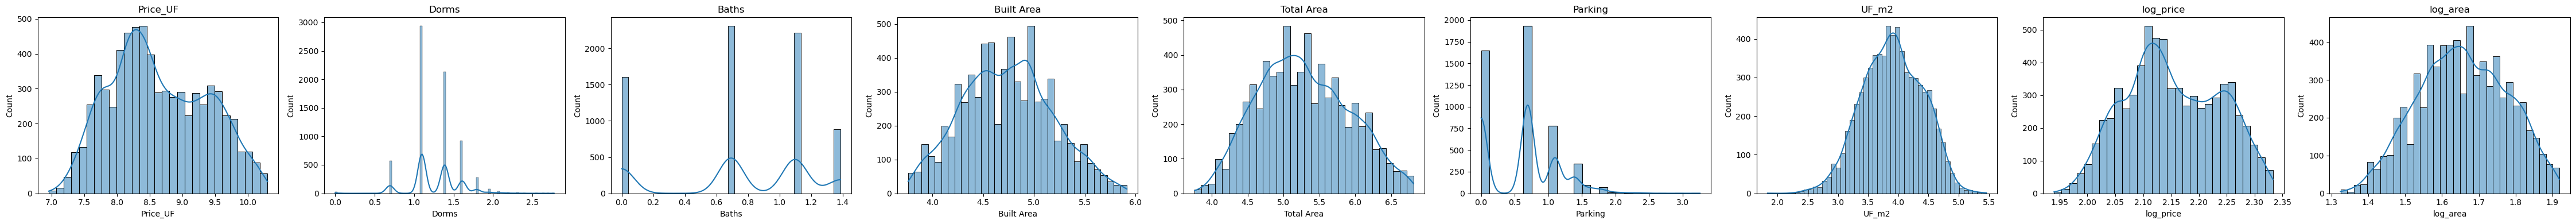

In [98]:
cols = df_clean.select_dtypes(include='number').columns

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols),4))
for i, col in enumerate(cols):
    sns.histplot(np.log(df_clean[col]), kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [80]:
df_clean.head()

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,Realtor
0,3600.0,Lampa,3,2,68.0,221.0,1,Behouse
1,3603.0,Buin,5,3,150.0,190.0,2,Desconocido
2,4795.0,PuenteAlto,4,3,90.0,182.0,3,Bissac
3,3750.0,Buin,3,2,85.0,175.0,1,Ambiento Propiedades
4,5405.0,QuintaNormal,3,3,130.0,402.0,1,Puntoinmobiliario.cl


Text(0, 0.5, 'Casas')

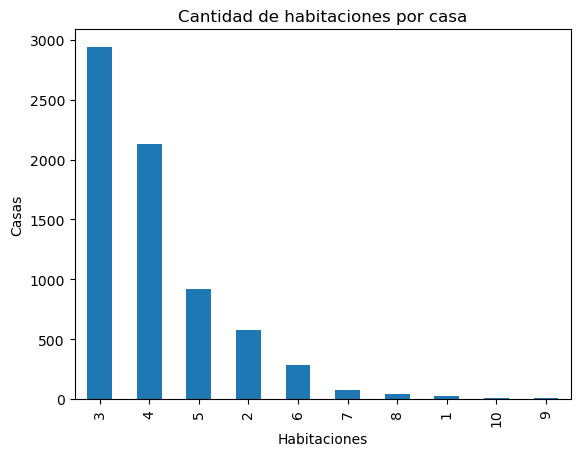

In [81]:
#plt.style.use('ggplot') #fivethirtyeight
ax = df_clean['Dorms'].value_counts().head(10)\
    .plot(kind='bar', 
          title='Cantidad de habitaciones por casa')
ax.set_xlabel('Habitaciones')
ax.set_ylabel('Casas')

Text(0, 0.5, 'Comuna')

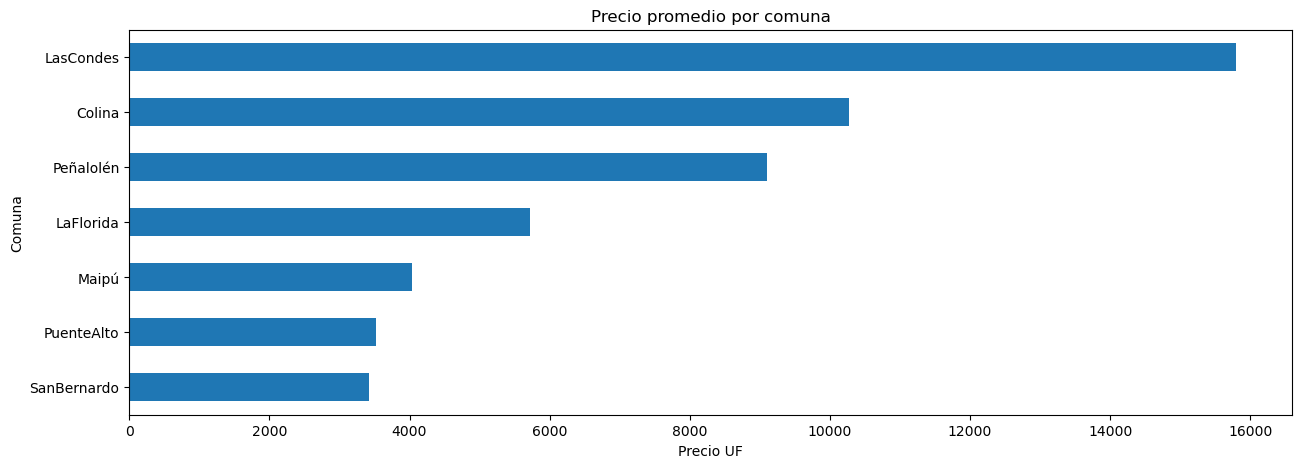

In [82]:
bx = df_clean.groupby('Comuna')['Price_UF'] \
    .agg(['mean', 'count']) \
    .query('count >= 250') \
    .sort_values('mean')['mean'] \
    .plot(kind='barh',
          figsize=(15,5),
          title='Precio promedio por comuna')
bx.set_xlabel('Precio UF')
bx.set_ylabel('Comuna')

Text(0, 0.5, 'Comuna')

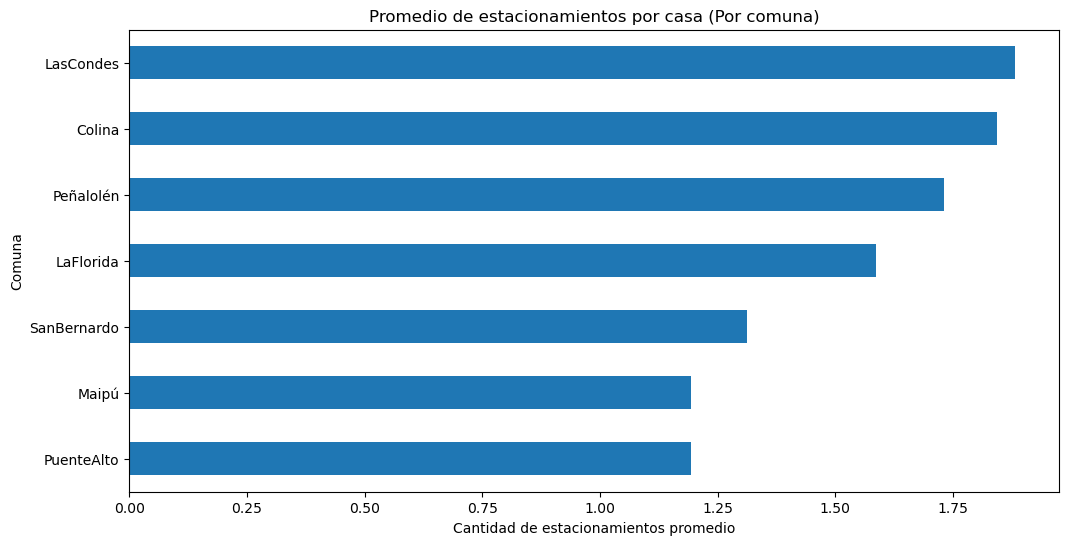

In [83]:
cx = (
    df_clean
    .groupby('Comuna')['Parking'] # Agrupa por comuna y selecciona solo la columna Parking para los valores
    .agg(['mean', 'count'])
    .query('count >= 250')
    .sort_values('mean')['mean'] # Ordena y se queda solo con 'mean' para graficar
    .plot(
        kind='barh',
        figsize=(12,6),
        title='Promedio de estacionamientos por casa (Por comuna)'
    )
)

cx.set_xlabel('Cantidad de estacionamientos promedio')
cx.set_ylabel('Comuna')

Text(0, 0.5, 'Comuna')

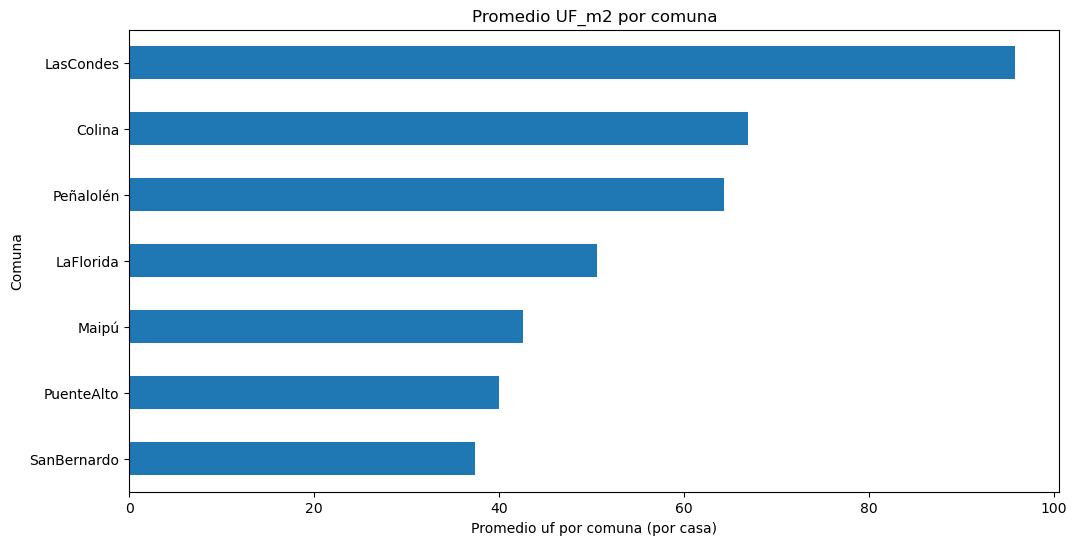

In [84]:
df_clean['UF_m2'] = (df_clean['Price_UF'] / df_clean['Built Area'])

dx = df_clean.groupby('Comuna')['UF_m2'] \
    .agg(['mean','count']) \
    .query('count > 250') \
    .sort_values('mean')['mean'] \
    .plot(
        kind='barh',
        figsize=(12,6),
        title='Promedio UF_m2 por comuna'
    )

dx.set_xlabel('Promedio uf por comuna (por casa)')
dx.set_ylabel('Comuna')

In [85]:
#corr = df_clean.drop(columns=['Comuna','id','Ubicacion','Realtor','Price_CLP','Price_USD']).corr()
corr = df_clean.select_dtypes('number').corr()
display(corr)

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking,UF_m2
Price_UF,1.000000,0.322744,0.599053,0.712846,0.752893,0.284024,0.790334
Dorms,0.322744,1.000000,0.408570,0.505198,0.313013,0.102073,0.068341
Baths,0.599053,0.408570,1.000000,0.557002,0.463456,0.221126,0.408023
Built Area,0.712846,0.505198,0.557002,1.000000,0.668924,0.227100,0.217973
Total Area,0.752893,0.313013,0.463456,0.668924,1.000000,0.319957,0.509671
Parking,0.284024,0.102073,0.221126,0.227100,0.319957,1.000000,0.227243
UF_m2,0.790334,0.068341,0.408023,0.217973,0.509671,0.227243,1.000000


<Axes: >

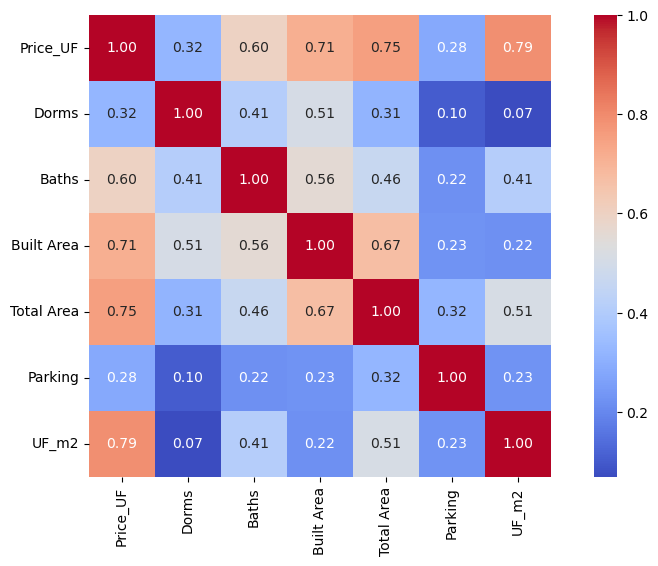

In [86]:
plt.figure(figsize=(11,6))
sns.heatmap(corr,
            cmap='coolwarm',
            square=True,
            fmt='.2f',
            annot=True)

In [87]:
df_clean['log_price'] = np.log(df_clean['Price_UF'])
df_clean['log_area'] = np.log(df_clean['Total Area'])
display(df_clean[['Price_UF','Total Area']].corr())
display(df_clean[['log_price','Total Area']].corr())
display(df_clean[['log_price','log_area']].corr())

,Price_UF,Total Area
Price_UF,1.000000,0.752893
Total Area,0.752893,1.000000


,log_price,Total Area
log_price,1.000000,0.738677
Total Area,0.738677,1.000000


,log_price,log_area
log_price,1.000000,0.795688
log_area,0.795688,1.000000


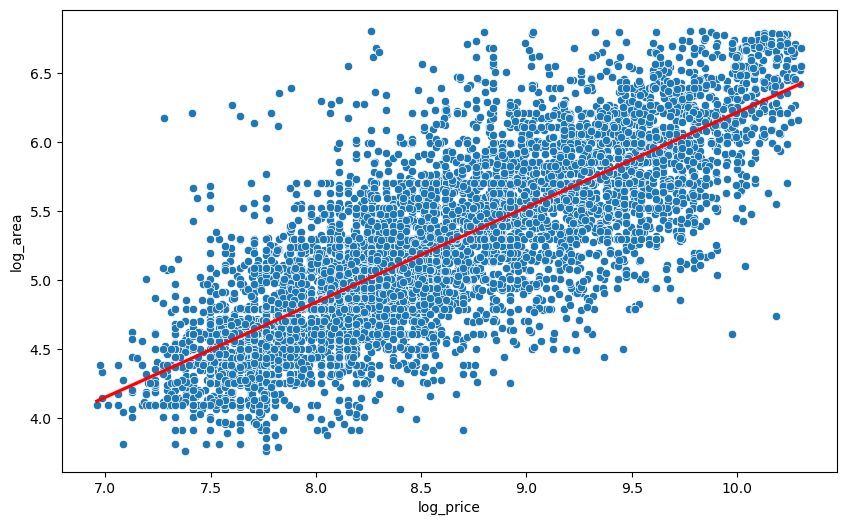

In [88]:
# Crear grafico de dispersion
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='log_price', y='log_area')

# Agregar linea de regresion
sns.regplot(data=df_clean, x='log_price', y='log_area', scatter=False, color='red')

plt.show()

In [89]:
df_clean.to_csv('../data/processed/casas_chile_limpio.csv', index=False)

In [90]:
resumen = (
    df_clean
    .groupby(['Comuna', 'Dorms'])
    .agg(
        precio_promedio=('Price_UF', 'mean'),
        precio_mediano=('Price_UF', 'median'),
        superficie_prom=('Built Area', 'mean'),
        uf_m2_prom=('UF_m2', 'mean'),
        cantidad=('Price_UF', 'count'),
    )
    .query('cantidad >= 30')           
    .sort_values(['Comuna', 'precio_promedio'], ascending=[True, False])
    .round(2)
)

umbral = 0.2
promedio_global = df_clean.groupby('Comuna')['UF_m2'].transform('mean') * umbral

df_clean['es_barata'] = (df_clean['UF_m2'] < promedio_global)

baratas = (
    df_clean
    .groupby(['Comuna'])
    .agg(
        promedio_comuna=('Price_UF', 'mean'),
        uf_m2_prom=('UF_m2','mean'),
        cantidad =('Price_UF', 'count'),
        casas_baratas=('es_barata', 'sum'),
        umbral = ('UF_m2', lambda x: x.mean() * umbral)
    )
    .query('cantidad >= 30')
    .sort_values('uf_m2_prom', ascending=False)
)

display(resumen)
display(df_clean[df_clean['UF_m2'] < promedio_global])
display(baratas)
#df_clean.drop(columns=['es_barata'], inplace=True)

precio_promedio  precio_mediano  superficie_prom  \
Comuna          Dorms                                                     
Buin            3          4747.419922          4275.5        92.650002   
Cerrillos       3          4049.270020          4158.0       110.910004   
Colina          5         13445.049805         13900.0       199.029999   
                4         11693.349609         12200.0       167.860001   
                3          9386.000000          9700.0       132.630005   
ElBosque        3          3317.800049          3042.0       102.349998   
EstaciónCentral 3          4408.439941          3850.0       112.760002   
Huechuraba      4          7795.399902          7500.0       144.190002   
                3          6495.279785          6000.0       110.500000   
LaFlorida       5          7367.799805          7100.0       148.899994   
                4          6523.740234          6403.0       126.239998   
                3          5186.629883          4573.0       103.120003   
LaReina         5         14732.169922         14045.0       184.520004   
                4         13716.959961         12750.0       165.059998   
                3         11088.450195         10948.0       132.300003   
Lampa           4          4083.969971          4213.0       114.129997   
                3          4002.239990          3850.0        86.639999   
LasCondes       5         18382.109375         18050.0       207.070007   
                6         17899.060547         16700.0       223.210007   
                4         16058.209961         15500.0       172.619995   
                3         13230.419922         12800.0       130.729996   
LoBarnechea     4         19086.539062         18700.0       199.860001   
                5         18945.189453         17900.0       198.419998   
Macul           4          6165.310059          6098.0       123.419998   
                3          5865.220215          5266.0       107.570000   
Maipú           5          5136.310059          4435.0       128.910004   
                4          4298.620117          4019.0       112.940002   
                3          3912.610107          3742.0        87.540001   
                2          2821.639893          2633.0        73.529999   
PadreHurtado    3          4020.709961          3457.5        90.489998   
Peñaflor        3          3585.520020          3850.0        88.269997   
Peñalolén       5         10208.370117         10500.0       157.880005   
                4          8967.500000          9000.0       143.220001   
                3          7978.720215          8020.0       117.940002   
Providencia     4         15641.830078         14500.0       173.679993   
Pudahuel        4          6023.640137          6490.0       123.099998   
                3          5614.000000          5266.0       109.690002   
PuenteAlto      5          4564.490234          4300.0       129.270004   
                4          3960.719971          3849.0       101.449997   
                3          3479.969971          3420.0        86.080002   
                2          2308.189941          2090.0        68.720001   
Quilicura       4          4388.379883          4435.0       104.820000   
                3          4163.819824          4200.0        90.040001   
Renca           3          3270.510010          3400.0        84.349998   
SanBernardo     3          3591.010010          3450.0        88.180000   
                4          3444.300049          3033.5       105.449997   
                2          2349.620117          2148.0        66.099998   
SanMiguel       4          9871.650391          9025.5       159.679993   
Santiago        4          6290.529785          5350.0       139.639999   
                3          4836.450195          4352.0       115.260002   
Vitacura        4         17628.369141         17200.0       175.970001   
                3         16108.320312         1

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,Realtor,UF_m2,log_price,log_area,es_barata
2209,1450.0,Colina,3,4,139.0,480.0,2,Mi Llave,10.431655,7.279319,6.173786,True
2840,1524.0,Colina,4,1,117.0,85.0,1,Desconocido,13.025641,7.329094,4.442651,True
3273,1926.0,Colina,5,2,168.0,108.0,1,Patricio Gajardo propiedades,11.464286,7.563200,4.682131,True
3329,2162.0,Colina,11,4,184.0,184.0,3,Agente Propiedades,11.750000,7.678789,5.214936,True
4081,1691.0,Colina,4,2,270.0,270.0,0,Urbalia,6.262963,7.433075,5.598422,True
7877,1386.0,Colina,3,1,130.0,90.0,0,Propiedades Centro Santiago SPA,10.661538,7.234177,4.499810,True


,promedio_comuna,uf_m2_prom,cantidad,casas_baratas,umbral
Comuna,,,,,
Vitacura,17402.720703,113.380798,158,0,22.676161
LasCondes,15802.322266,95.807327,599,0,19.161465
LoBarnechea,18463.218750,94.357414,187,0,18.871483
Providencia,15431.525391,86.673775,120,0,17.334755
LaReina,13093.928711,82.871758,237,0,16.574352
Ñuñoa,11200.743164,75.776253,226,0,15.155251
Colina,10269.937500,66.876091,429,6,13.375218
Peñalolén,9105.668945,64.320236,296,0,12.864047
SanMiguel,8978.949219,60.616745,98,0,12.123349


In [91]:
# Tabla 1: Resumen por comuna
resumen_comuna = (
    df_clean
    .groupby('Comuna')
    .agg(
        precio_promedio = ('Price_UF', 'mean'),
        uf_m2_promedio = ('UF_m2', 'mean'),
        total_propiedades = ('Price_UF', 'count')
    )
    .reset_index()
)

# Tabla 2: Comunas premium
premium = (
    df_clean
    .groupby('Comuna')
    .agg(
        precio_maximo=('Price_UF','max'),
        superficie_maxima=('Total Area','max'),
    )
    .reset_index()
)

# Join entre columnas
analisis_comunas = pd.merge(
    resumen_comuna,             # Left
    premium,                    # Right
    how = 'inner',              # Tipo de join, inner, outer, left, right
    on = 'Comuna',              # Sobre que columna se va a realizar
).sort_values('precio_promedio', ascending=False)

display(analisis_comunas)

,Comuna,precio_promedio,uf_m2_promedio,total_propiedades,precio_maximo,superficie_maxima
20,LoBarnechea,18463.218750,94.357414,187,29900.0,886.0
47,Vitacura,17402.720703,113.380798,158,29774.0,640.0
19,LasCondes,15802.322266,95.807327,599,29800.0,900.0
32,Providencia,15431.525391,86.673775,120,29000.0,890.0
17,LaReina,13093.928711,82.871758,237,29000.0,860.0
48,Ñuñoa,11200.743164,75.776253,226,28000.0,784.0
4,Colina,10269.937500,66.876091,429,24000.0,908.0
30,Peñalolén,9105.668945,64.320236,296,19990.0,900.0
42,SanMiguel,8978.949219,60.616745,98,22990.0,836.0
10,Huechuraba,7395.612305,57.527977,116,13300.0,490.0


In [92]:
analisis_comunas = (
    df_clean.
    groupby('Comuna')
    .agg(
        precio_promedio = ('Price_UF','mean'),
        uf_m2_promedio = ('UF_m2', 'mean'),
        total_propiedades = ('Price_UF', 'count'),
        precio_maximo = ('Price_UF', 'max'),
        superficie_maxima = ('Total Area', 'max'),
    )
    .query('total_propiedades > 30')
    .sort_values('precio_promedio', ascending = False)
    .reset_index()
)
analisis_comunas

,Comuna,precio_promedio,uf_m2_promedio,total_propiedades,precio_maximo,superficie_maxima
0,LoBarnechea,18463.218750,94.357414,187,29900.0,886.0
1,Vitacura,17402.720703,113.380798,158,29774.0,640.0
2,LasCondes,15802.322266,95.807327,599,29800.0,900.0
3,Providencia,15431.525391,86.673775,120,29000.0,890.0
4,LaReina,13093.928711,82.871758,237,29000.0,860.0
5,Ñuñoa,11200.743164,75.776253,226,28000.0,784.0
6,Colina,10269.937500,66.876091,429,24000.0,908.0
7,Peñalolén,9105.668945,64.320236,296,19990.0,900.0
8,SanMiguel,8978.949219,60.616745,98,22990.0,836.0
9,Huechuraba,7395.612305,57.527977,116,13300.0,490.0


In [93]:
df_clean['Price_UF_millones'] = df_clean['Price_UF'] * 39000 # Broadcasting, escalar una columna entera

display(df_clean.head().select_dtypes('number').style.format("{:,.2f}"))

df_clean.drop(columns='Price_UF_millones', inplace=True)

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking,UF_m2,log_price,log_area,Price_UF_millones
0,"3,600.00",3.00,2.00,68.00,221.00,1.00,52.94,8.19,5.40,"140,400,000.00"
1,"3,603.00",5.00,3.00,150.00,190.00,2.00,24.02,8.19,5.25,"140,516,992.00"
2,"4,795.00",4.00,3.00,90.00,182.00,3.00,53.28,8.48,5.20,"187,004,992.00"
3,"3,750.00",3.00,2.00,85.00,175.00,1.00,44.12,8.23,5.16,"146,250,000.00"
4,"5,405.00",3.00,3.00,130.00,402.00,1.00,41.58,8.60,6.00,"210,795,008.00"


In [94]:
pivot_dorms = (
    df_clean
    .groupby(['Comuna', 'Dorms'])['Price_UF']
    .mean()
    .round(0)
    .unstack(fill_value=0)  # Dorms pasan a ser columnas
)

display(pivot_dorms)

Dorms,1,2,3,4,5,6,7,8,9,10,11,13,14,15,16
Comuna,,,,,,,,,,,,,,,
Buin,0.0,2627.0,4747.0,5968.0,4848.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CaleradeTango,0.0,0.0,3695.0,3090.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cerrillos,0.0,5124.0,4049.0,4280.0,4944.0,5294.0,5100.0,3326.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CerroNavia,5543.0,2080.0,3649.0,2935.0,3742.0,3808.0,3448.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Colina,1247.0,3479.0,9386.0,11693.0,13445.0,18700.0,0.0,0.0,0.0,0.0,2162.0,0.0,0.0,0.0,0.0
Conchalí,0.0,2923.0,3873.0,4250.0,4186.0,7207.0,6166.0,0.0,0.0,0.0,0.0,4158.0,4435.0,0.0,0.0
Curacaví,0.0,0.0,4338.0,3013.0,5543.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ElBosque,0.0,2704.0,3318.0,3448.0,4567.0,3988.0,3049.0,0.0,3769.0,0.0,4166.0,0.0,0.0,0.0,0.0
ElMonte,0.0,1524.0,2888.0,5900.0,0.0,1996.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
# De ancho (cada metrica es columna) a largo (una fila por metrica)
resumen_largo = resumen_comuna.melt(
    id_vars='Comuna',
    value_vars=['precio_promedio', 'uf_m2_promedio'],
    var_name='metrica',
    value_name='valor'
)

display(resumen_largo)

,Comuna,metrica,valor
0,Buin,precio_promedio,4783.913574
1,CaleradeTango,precio_promedio,3453.199951
2,Cerrillos,precio_promedio,4332.471191
3,CerroNavia,precio_promedio,3370.399902
4,Colina,precio_promedio,10269.937500
...,...,...,...
93,Santiago,uf_m2_promedio,41.790760
94,Talagante,uf_m2_promedio,39.678932
95,Tiltil,uf_m2_promedio,45.117191
96,Vitacura,uf_m2_promedio,113.380798
